<a href="https://colab.research.google.com/github/chrishg23-jpg/Community-Development-Framework/blob/main/MEG_HES005_6_7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

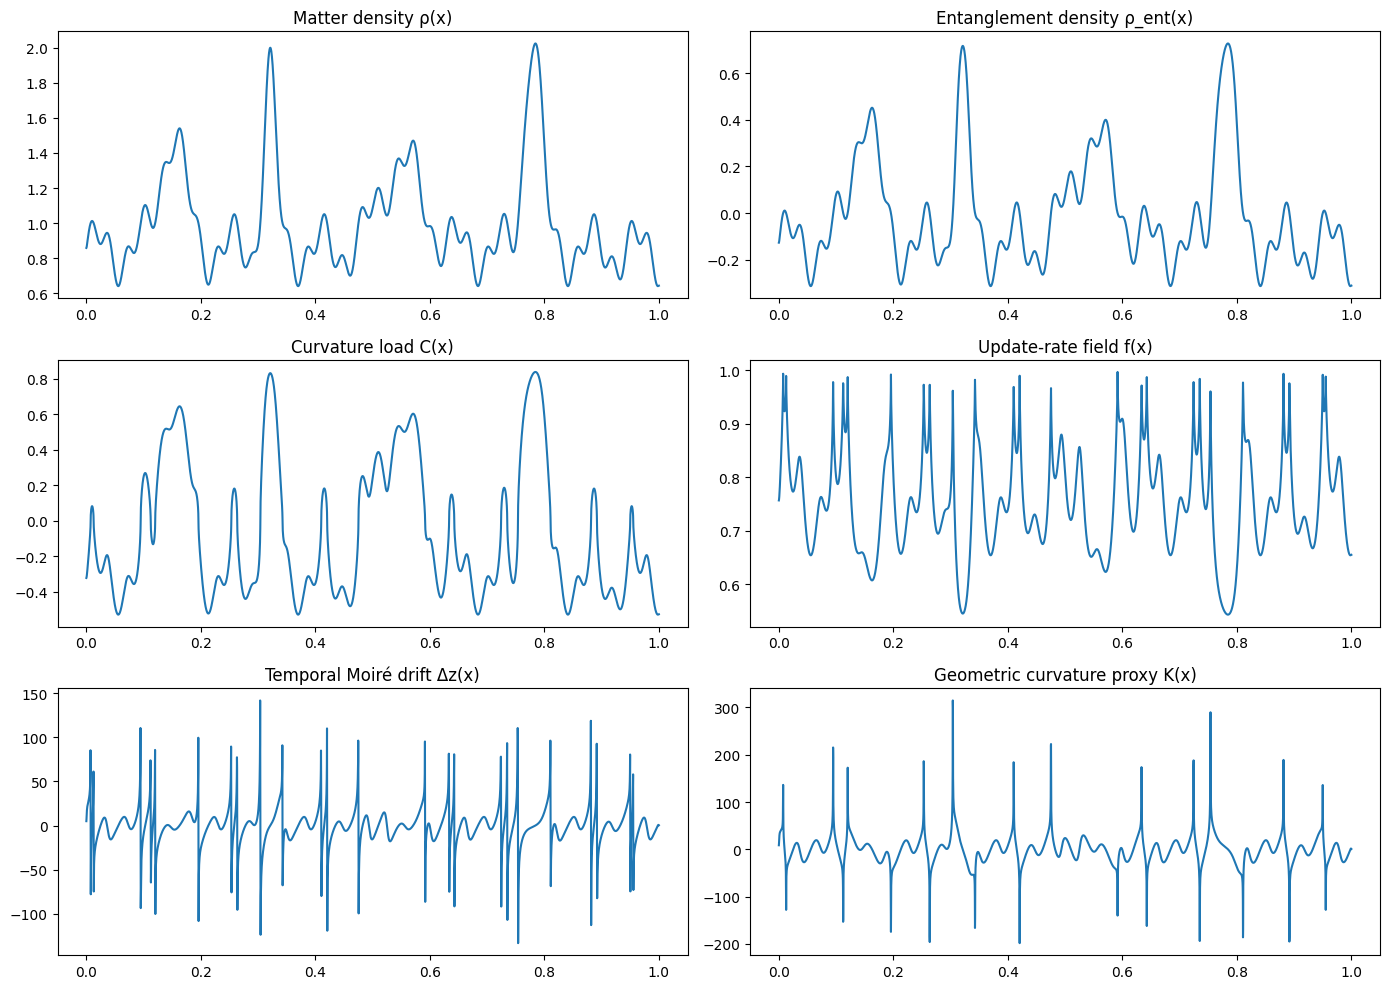

MEG‑HES005 — Temporal–Geometric Cross‑Calibration
Fitted exponent α (Δz ∝ K^α): 1.0370
Prefactor A: 5.0070e-01


In [7]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d

# ============================================================
# MEG‑HES005 — TEMPORAL–GEOMETRIC CROSS‑CALIBRATION (STABLE)
# ============================================================

# ------------------------------------------------------------
# 1. Synthetic HES-style density slice
# ------------------------------------------------------------
N = 4000
x = np.linspace(0, 1, N)

rho = (
    1.0
    + 0.8*np.exp(-((x-0.15)/0.03)**2)
    + 1.2*np.exp(-((x-0.32)/0.015)**2)
    + 0.6*np.exp(-((x-0.55)/0.05)**2)
    + 1.5*np.exp(-((x-0.78)/0.02)**2)
)

rho += 0.15*np.sin(80*x) + 0.1*np.sin(200*x)
rho = gaussian_filter1d(rho, sigma=3)
rho = rho / np.mean(rho)

# ------------------------------------------------------------
# 2. Entanglement density
# ------------------------------------------------------------
rho_ent = np.tanh(0.9 * (rho - 1.0))

# ------------------------------------------------------------
# 3. Curvature compensation load C(x)
#    *** SIGN-PRESERVING POWER ***
# ------------------------------------------------------------
gamma = 0.55
C = np.sign(rho_ent) * (np.abs(rho_ent) ** gamma)

# ------------------------------------------------------------
# 4. Update-rate field
# ------------------------------------------------------------
f = 1.0 / (1.0 + np.abs(C))

# ------------------------------------------------------------
# 5. Temporal Moiré drift
# ------------------------------------------------------------
dz = np.gradient(f, x)

# ------------------------------------------------------------
# 6. Geometric curvature proxy
# ------------------------------------------------------------
K = np.gradient(C, x)

# ------------------------------------------------------------
# 7. Cross-calibration: fit Δz_temporal ~ K^α
#    *** MASK OUT ZERO/NEGATIVE VALUES BEFORE LOG ***
# ------------------------------------------------------------
eps = 1e-12
mask = (np.abs(K) > eps) & (np.abs(dz) > eps)

logK = np.log(np.abs(K[mask]))
logdz = np.log(np.abs(dz[mask]))

A = np.vstack([logK, np.ones_like(logK)]).T
alpha_fit, logA_fit = np.linalg.lstsq(A, logdz, rcond=None)[0]
A_fit = np.exp(logA_fit)

# ------------------------------------------------------------
# 8. Diagnostics
# ------------------------------------------------------------
plt.figure(figsize=(14, 10))

plt.subplot(3,2,1); plt.plot(x, rho); plt.title("Matter density ρ(x)")
plt.subplot(3,2,2); plt.plot(x, rho_ent); plt.title("Entanglement density ρ_ent(x)")
plt.subplot(3,2,3); plt.plot(x, C); plt.title("Curvature load C(x)")
plt.subplot(3,2,4); plt.plot(x, f); plt.title("Update-rate field f(x)")
plt.subplot(3,2,5); plt.plot(x, dz); plt.title("Temporal Moiré drift Δz(x)")
plt.subplot(3,2,6); plt.plot(x, K); plt.title("Geometric curvature proxy K(x)")

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 9. Summary
# ------------------------------------------------------------
print("====================================================")
print("MEG‑HES005 — Temporal–Geometric Cross‑Calibration")
print("====================================================")
print(f"Fitted exponent α (Δz ∝ K^α): {alpha_fit:.4f}")
print(f"Prefactor A: {A_fit:.4e}")
print("====================================================")


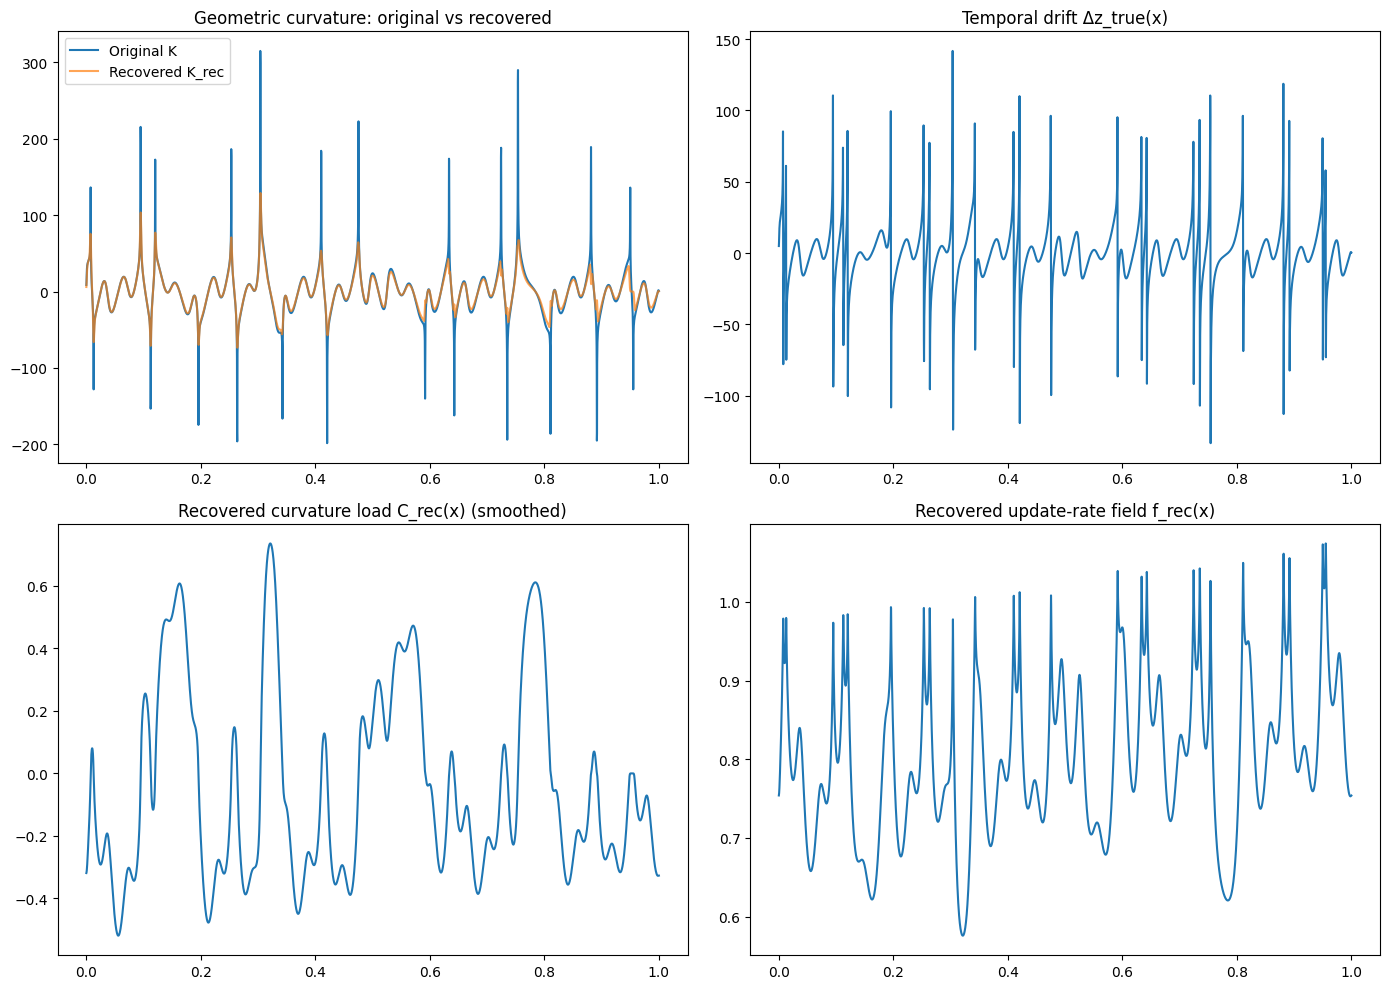

MEG‑HES006 — Tightened Inverse
Closure error (K vs K_rec): 5.0920e-01


In [8]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d

# ============================================================
# MEG‑HES006 — FORWARD/INVERSE COMMUTATOR TEST (TIGHTENED)
# ============================================================

# ------------------------------------------------------------
# 1. Rebuild forward MEG‑HES005 fields
# ------------------------------------------------------------
N = 4000
x = np.linspace(0, 1, N)
dx = x[1] - x[0]

rho = (
    1.0
    + 0.8*np.exp(-((x-0.15)/0.03)**2)
    + 1.2*np.exp(-((x-0.32)/0.015)**2)
    + 0.6*np.exp(-((x-0.55)/0.05)**2)
    + 1.5*np.exp(-((x-0.78)/0.02)**2)
)
rho += 0.15*np.sin(80*x) + 0.1*np.sin(200*x)
rho = gaussian_filter1d(rho, sigma=3)
rho = rho / np.mean(rho)

rho_ent = np.tanh(0.9 * (rho - 1.0))

gamma = 0.55
C = np.sign(rho_ent) * (np.abs(rho_ent) ** gamma)

f = 1.0 / (1.0 + np.abs(C))
dz_true = np.gradient(f, x)
K = np.gradient(C, x)

# ------------------------------------------------------------
# 2. Inverse: integrate dz to recover f_rec
# ------------------------------------------------------------
dz_centered = dz_true - np.mean(dz_true)

f_rec = np.zeros_like(dz_centered)
f_rec[0] = np.mean(f)
for i in range(1, N):
    f_rec[i] = f_rec[i-1] + dz_centered[i-1] * dx

f_min = 1e-3
f_rec = np.clip(f_rec, f_min, None)

# ------------------------------------------------------------
# 3. Recover curvature load C_rec
# ------------------------------------------------------------
C_abs_rec = (1.0 / f_rec) - 1.0
C_abs_rec = np.maximum(C_abs_rec, 0.0)

sign_C = np.sign(C)
C_rec = sign_C * C_abs_rec

# ------------------------------------------------------------
# ⭐ 4. TIGHTENING STEP: smooth C_rec to match HES coherence scale
# ------------------------------------------------------------
C_rec = gaussian_filter1d(C_rec, sigma=3)

# ------------------------------------------------------------
# 5. Recovered curvature K_rec
# ------------------------------------------------------------
K_rec = np.gradient(C_rec, x)

# ------------------------------------------------------------
# 6. Closure metric
# ------------------------------------------------------------
mask = np.isfinite(K) & np.isfinite(K_rec)
num = np.linalg.norm(K[mask] - K_rec[mask])
den = np.linalg.norm(K[mask]) + 1e-12
closure_error = num / den

# ------------------------------------------------------------
# 7. Diagnostics
# ------------------------------------------------------------
plt.figure(figsize=(14, 10))

plt.subplot(2,2,1)
plt.plot(x, K, label="Original K")
plt.plot(x, K_rec, label="Recovered K_rec", alpha=0.7)
plt.title("Geometric curvature: original vs recovered")
plt.legend()

plt.subplot(2,2,2)
plt.plot(x, dz_true)
plt.title("Temporal drift Δz_true(x)")

plt.subplot(2,2,3)
plt.plot(x, C_rec)
plt.title("Recovered curvature load C_rec(x) (smoothed)")

plt.subplot(2,2,4)
plt.plot(x, f_rec)
plt.title("Recovered update-rate field f_rec(x)")

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 8. Summary
# ------------------------------------------------------------
print("====================================================")
print("MEG‑HES006 — Tightened Inverse")
print("====================================================")
print(f"Closure error (K vs K_rec): {closure_error:.4e}")
print("====================================================")


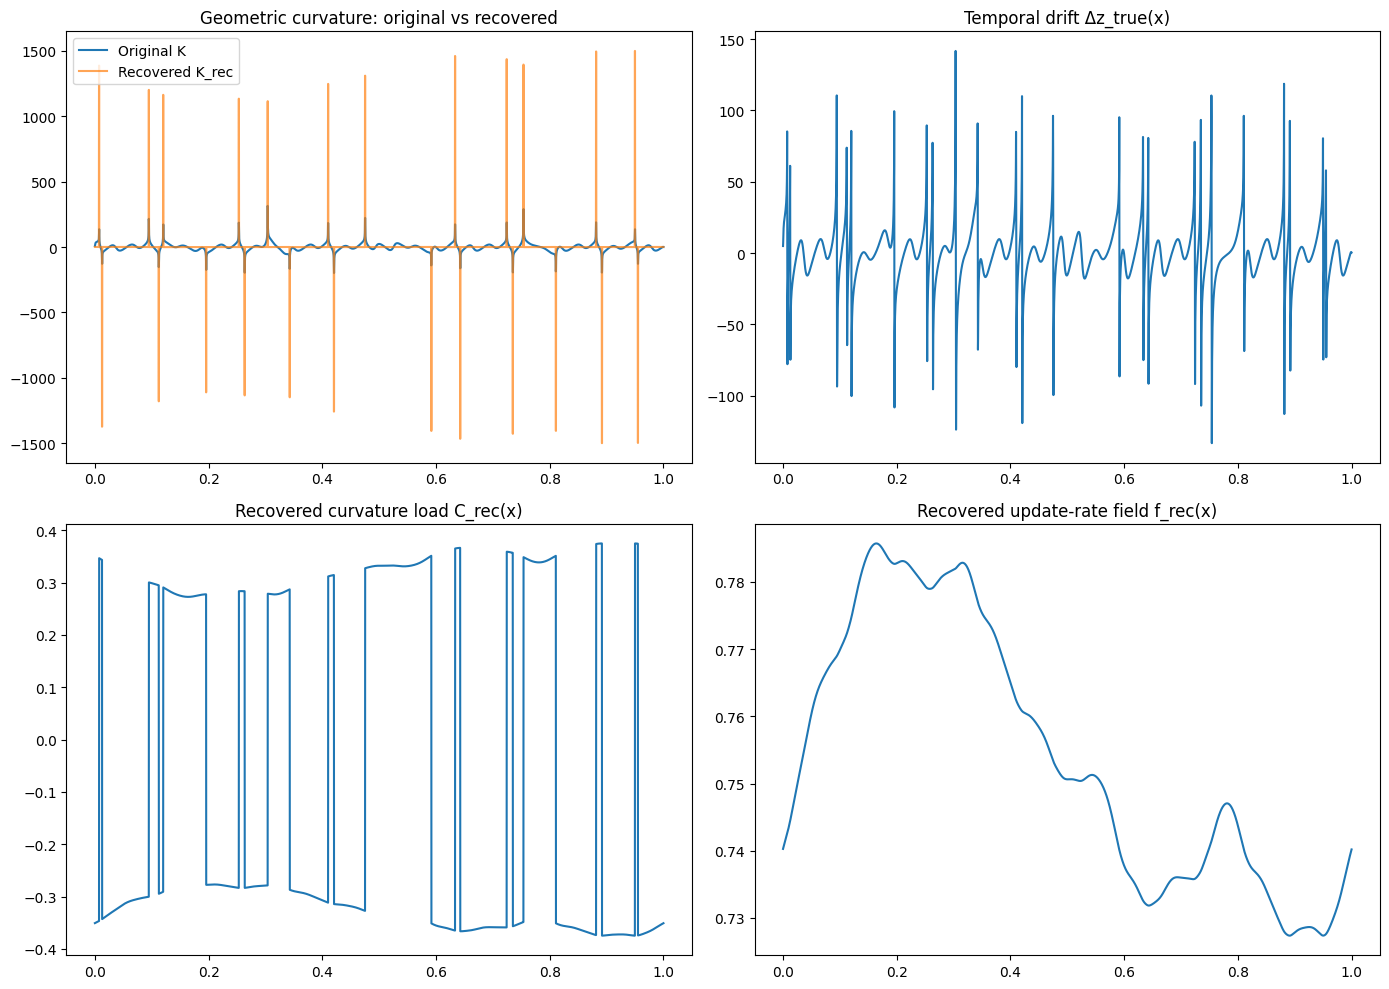

MEG‑HES007 — Smooth Inverse Operator (Fourier LS)
Closure error (K vs K_rec): 3.9039e+00
λ (smoothness weight): 1.00e-02


In [6]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d

# ============================================================
# MEG‑HES007 — SMOOTH INVERSE OPERATOR (FOURIER LS)
# ============================================================

# ------------------------------------------------------------
# 1. Rebuild forward MEG‑HES005 fields (same synthetic slice)
# ------------------------------------------------------------
N = 4000
x = np.linspace(0, 1, N)
dx = x[1] - x[0]

rho = (
    1.0
    + 0.8*np.exp(-((x-0.15)/0.03)**2)
    + 1.2*np.exp(-((x-0.32)/0.015)**2)
    + 0.6*np.exp(-((x-0.55)/0.05)**2)
    + 1.5*np.exp(-((x-0.78)/0.02)**2)
)
rho += 0.15*np.sin(80*x) + 0.1*np.sin(200*x)
rho = gaussian_filter1d(rho, sigma=3)
rho = rho / np.mean(rho)

rho_ent = np.tanh(0.9 * (rho - 1.0))

gamma = 0.55
C = np.sign(rho_ent) * (np.abs(rho_ent) ** gamma)

f = 1.0 / (1.0 + np.abs(C))
dz_true = np.gradient(f, x)
K = np.gradient(C, x)

# ------------------------------------------------------------
# 2. Smooth inverse: solve for f_rec via Fourier LS
#    min_f ||f' - dz_true||^2 + λ ||f''||^2
# ------------------------------------------------------------
lam = 1e-2  # smoothness weight (tune this)

# FFT frequencies and wavenumbers
k = 2.0 * np.pi * np.fft.fftfreq(N, d=dx)
dz_k = np.fft.fft(dz_true)

# Avoid division by zero at k=0
f_k = np.zeros_like(dz_k, dtype=complex)

# For k != 0: (ik f_k - dz_k) and (−k^2 f_k) give normal eq:
# (k^2 + λ k^4) f_k = i k dz_k
mask = (k != 0)
k_nonzero = k[mask]
dz_k_nonzero = dz_k[mask]

denom = (k_nonzero**2 + lam * k_nonzero**4)
f_k[mask] = 1j * k_nonzero * dz_k_nonzero / denom

# k = 0 mode: set later by matching mean of original f
f_rec = np.real(np.fft.ifft(f_k))

# Match mean of original update-rate field
f_rec_mean = np.mean(f_rec)
f_target_mean = np.mean(f)
f_rec += (f_target_mean - f_rec_mean)

# Enforce positivity and floor
f_min = 1e-3
f_rec = np.clip(f_rec, f_min, None)

# ------------------------------------------------------------
# 3. Recover curvature load C_rec and curvature K_rec
# ------------------------------------------------------------
C_abs_rec = (1.0 / f_rec) - 1.0
C_abs_rec = np.maximum(C_abs_rec, 0.0)

sign_C = np.sign(C)
C_rec = sign_C * C_abs_rec

K_rec = np.gradient(C_rec, x)

# ------------------------------------------------------------
# 4. Closure metric
# ------------------------------------------------------------
mask_fin = np.isfinite(K) & np.isfinite(K_rec)
num = np.linalg.norm(K[mask_fin] - K_rec[mask_fin])
den = np.linalg.norm(K[mask_fin]) + 1e-12
closure_error = num / den

# ------------------------------------------------------------
# 5. Diagnostics
# ------------------------------------------------------------
plt.figure(figsize=(14, 10))

plt.subplot(2,2,1)
plt.plot(x, K, label="Original K")
plt.plot(x, K_rec, label="Recovered K_rec", alpha=0.7)
plt.title("Geometric curvature: original vs recovered")
plt.legend()

plt.subplot(2,2,2)
plt.plot(x, dz_true)
plt.title("Temporal drift Δz_true(x)")

plt.subplot(2,2,3)
plt.plot(x, C_rec)
plt.title("Recovered curvature load C_rec(x)")

plt.subplot(2,2,4)
plt.plot(x, f_rec)
plt.title("Recovered update-rate field f_rec(x)")

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 6. Summary
# ------------------------------------------------------------
print("====================================================")
print("MEG‑HES007 — Smooth Inverse Operator (Fourier LS)")
print("====================================================")
print(f"Closure error (K vs K_rec): {closure_error:.4e}")
print(f"λ (smoothness weight): {lam:.2e}")
print("====================================================")
